# IAM Handwriting Recognition Benchmark Analysis

### Executive Summary
**Dataset:** IAM Mini - Handwriting Recognition  
**Total Samples:** 500 handwritten text images per phase  
**Task:** Optical Character Recognition (OCR) of cursive and print handwriting  
**Evaluation Metrics:** CER (Character Error Rate), WER (Word Error Rate), ANLS (Average Normalized Levenshtein Similarity), Cosine Similarity

### Benchmark Structure

Phase Pa: OCR Baseline (Pure OCR Models)
- **Models:** Azure Document Intelligence, Mistral Document AI
- **Approach:** Direct OCR on handwritten text
- **Purpose:** Establish baseline OCR performance for handwriting recognition

Phase Pb: VLM Baseline (Generic Prompting)
- **Models:** GPT-5-mini, GPT-5-nano, Claude Sonnet  
- **Prompt:** Generic text extraction (no handwriting context)
- **Purpose:** Evaluate general-purpose VLM capabilities for handwriting OCR

Phase Pc: VLM with Task-Aware Prompting
- **Models:** GPT-5-mini, GPT-5-nano, Claude Sonnet
- **Prompt:** Handwriting-specific instructions
- **Purpose:** Evaluate impact of task-aware prompting on handwriting recognition

# 1. Imports and Metadata

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import sys
from pathlib import Path
from typing import List, Dict, Optional, Tuple
import warnings
warnings.filterwarnings('ignore')

# Progress bar for long operations
from tqdm.notebook import tqdm

# Add parent directory to path for imports
sys.path.insert(0, str(Path.cwd().parent.parent.parent))

# Import evaluation metrics
from ocr_vs_vlm.metrics.evaluation_metrics import (
    calculate_cer,
    calculate_wer,
    compute_anls,
    compute_exact_match,
    compute_ground_truth_in_prediction
)

# Import embedding cache manager for efficient cosine similarity computation
from ocr_vs_vlm.metrics.embedding_cache import EmbeddingCacheManager

# Import model ordering configuration for consistent display
sys.path.insert(0, str(Path.cwd().parent))
from utils.model_order import MODEL_ORDER, sort_models, get_model_display_name

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 1000)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

print("Libraries and evaluation metrics loaded successfully!")
print(f"Model display order: {', '.join(MODEL_ORDER)}")

Libraries and evaluation metrics loaded successfully!
Model display order: azure_intelligence, mistral_document_ai, gpt-5-nano, gpt-5-mini, claude_sonnet


In [26]:
# Define metric calculation helper function
def calculate_sample_metrics(
    ground_truth: str, 
    prediction: str,
    phase: str,
    sample_id: str,
    model: str,
    emb_manager
) -> Dict[str, float]:
    """Calculate all metrics for a single sample with cached embeddings."""
    if pd.isna(prediction) or prediction == "":
        return {
            'cer': 1.0,
            'wer': 1.0,
            'anls': 0.0,
            'cosine_similarity': 0.0,
            'ground_truth_in_prediction': 0.0,
        }
    
    # Use embedding manager for cosine similarity (with caching)
    cosine_sim = emb_manager.compute_cosine_similarity(
        phase=phase,
        ground_truth=ground_truth,
        prediction=str(prediction),
        sample_id=sample_id,
        model=model
    )
    
    return {
        'cer': calculate_cer(ground_truth, prediction),
        'wer': calculate_wer(ground_truth, prediction),
        'anls': compute_anls(str(prediction), [ground_truth]),
        'cosine_similarity': cosine_sim,
        'ground_truth_in_prediction': compute_ground_truth_in_prediction(str(prediction), [ground_truth]),

    }

### Find csvs per phase

In [27]:
# Define paths
RESULTS_DIR = Path("../../2_clean/IAM_mini")

# Check available files
available_files = list(RESULTS_DIR.glob("*.csv"))
print("Available files:")
for f in sorted(available_files):
    print(f"  - {f.name}")

Available files:
  - Pa.csv
  - Pb.csv
  - Pc.csv
  - phase_1.csv
  - phase_2.csv
  - phase_3.csv


### Find embeddings

In [28]:
# Dataset configuration
DATASET_NAME = "IAM_mini"

# Initialize embedding cache manager
# This will load any previously computed embeddings from 3_embeddings/
EMBEDDINGS_DIR = Path("../../3_embeddings")
embedding_manager = EmbeddingCacheManager(DATASET_NAME, EMBEDDINGS_DIR)

print(f"📁 Dataset: {DATASET_NAME}")
print(f"📂 Embeddings directory: {EMBEDDINGS_DIR.resolve()}")
if embedding_manager.cache:
    print(f"✅ Loaded cached embeddings for phases: {', '.join(embedding_manager.cache.keys())}")
else:
    print("⚠️ No cached embeddings found - will compute on first run and save for future use")

📁 Dataset: IAM_mini
📂 Embeddings directory: /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/3_embeddings
✅ Loaded cached embeddings for phases: Pb, Pc, Pa


### Check datasets

In [29]:
# Load results for each phase
phase_dfs = {}

for phase in ['Pa', 'Pb', 'Pc']:
    file_path = RESULTS_DIR / f"{phase}.csv"
    if file_path.exists():
        phase_dfs[phase] = pd.read_csv(file_path)
        print(f"{phase}: {phase_dfs[phase].shape[0]} samples, {phase_dfs[phase].shape[1]} columns")
    else:
        print(f"{phase}: Not available")

print(f"\nTotal phases loaded: {len(phase_dfs)}")

Pa: 500 samples, 13 columns
Pb: 500 samples, 17 columns
Pc: 500 samples, 17 columns

Total phases loaded: 3


In [30]:
# Inspect column names for each phase
for phase, df in phase_dfs.items():
    print(f"\n{phase} columns:")
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    models = [col.replace('prediction_', '') for col in pred_cols]
    print(f"  Models: {', '.join(models)}")
    print(f"  Ground truth column: {'ground_truth' if 'ground_truth' in df.columns else 'NOT FOUND'}")
    print(f"  Total columns: {len(df.columns)}")


Pa columns:
  Models: azure_intelligence, mistral_document_ai
  Ground truth column: ground_truth
  Total columns: 13

Pb columns:
  Models: claude_sonnet, gpt-5-mini, gpt-5-nano
  Ground truth column: ground_truth
  Total columns: 17

Pc columns:
  Models: claude_sonnet, gpt-5-mini, gpt-5-nano
  Ground truth column: ground_truth
  Total columns: 17


### Data Quality Assesment

In [31]:
# Function to identify valid rows (exclude empty predictions and errors)
def is_valid_row(row, pred_col, err_col=None):
    """Check if a row has valid prediction (non-empty, no error)."""
    # Check if prediction is empty
    pred_value = row[pred_col]
    if pd.isna(pred_value) or str(pred_value).strip() == "":
        return False
    
    # Check if there's an error column and it has an error
    if err_col and err_col in row.index:
        if pd.notna(row[err_col]) and str(row[err_col]).strip() != "":
            return False
    
    return True

# Assess data quality for all phases
print("=" * 120)
print("DATA QUALITY ASSESSMENT")
print("=" * 120)

quality_stats = []

for phase, df in phase_dfs.items():
    print(f"\n📊 {phase} - Total rows: {len(df)}")
    
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Count valid and invalid rows
        empty_count = 0
        error_count = 0
        valid_count = 0
        
        for _, row in df.iterrows():
            if is_valid_row(row, pred_col, err_col):
                valid_count += 1
            else:
                # Check what type of invalid
                if pd.isna(row[pred_col]) or str(row[pred_col]).strip() == "":
                    empty_count += 1
                elif err_col in df.columns and pd.notna(row[err_col]):
                    error_count += 1
        
        invalid_count = empty_count + error_count
        valid_pct = (valid_count / len(df)) * 100
        
        print(f"  {model}:")
        print(f"    ✅ Valid rows: {valid_count}/{len(df)} ({valid_pct:.1f}%)")
        if invalid_count > 0:
            print(f"    ⚠️  Empty predictions: {empty_count}")
            if error_count > 0:
                print(f"    ❌ Errors logged: {error_count}")
        
        quality_stats.append({
            'Phase': phase,
            'Model': model,
            'Total Rows': len(df),
            'Valid Rows': valid_count,
            'Empty Predictions': empty_count,
            'Errors': error_count,
            'Valid %': valid_pct
        })

# Create summary DataFrame
quality_df = pd.DataFrame(quality_stats)

print("\n" + "=" * 120)
print("QUALITY SUMMARY - Models with Issues")
print("=" * 120)

# Show only models with issues
issues_df = quality_df[quality_df['Valid %'] < 100].sort_values('Valid %')
if len(issues_df) > 0:
    display(issues_df)
    print(f"\n⚠️  Found {len(issues_df)} model-phase combinations with data quality issues")
    print("These rows will be EXCLUDED from all metric calculations")
else:
    print("✅ All models have 100% valid data - no filtering needed!")

print("\n" + "=" * 120)

DATA QUALITY ASSESSMENT

📊 Pa - Total rows: 500
  azure_intelligence:
    ✅ Valid rows: 500/500 (100.0%)
  mistral_document_ai:
    ✅ Valid rows: 500/500 (100.0%)

📊 Pb - Total rows: 500
  claude_sonnet:
    ✅ Valid rows: 500/500 (100.0%)
  gpt-5-mini:
    ✅ Valid rows: 497/500 (99.4%)
    ⚠️  Empty predictions: 3
  gpt-5-nano:
    ✅ Valid rows: 500/500 (100.0%)

📊 Pc - Total rows: 500
  claude_sonnet:
    ✅ Valid rows: 500/500 (100.0%)
  gpt-5-mini:
    ✅ Valid rows: 497/500 (99.4%)
    ⚠️  Empty predictions: 3
  gpt-5-nano:
    ✅ Valid rows: 500/500 (100.0%)

QUALITY SUMMARY - Models with Issues


,Phase,Model,Total Rows,Valid Rows,Empty Predictions,Errors,Valid %
3,Pb,gpt-5-mini,500,497,3,0,99.4
6,Pc,gpt-5-mini,500,497,3,0,99.4



⚠️  Found 2 model-phase combinations with data quality issues
These rows will be EXCLUDED from all metric calculations



### Metrics calculation

In [32]:
# Import for incremental saving
from ocr_vs_vlm.metrics.embedding_cache import save_embeddings_for_phase

# Calculate metrics for all phases and models
metrics_results = {}

for phase, df in phase_dfs.items():
    print(f"\n📊 Calculating metrics for {phase}...")
    
    # Get all prediction columns
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    phase_metrics = {}
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Filter to only valid rows
        valid_rows = []
        for _, row in df.iterrows():
            if is_valid_row(row, pred_col, err_col):
                valid_rows.append(row)
        
        print(f"   Processing model: {model}")
        print(f"   Using {len(valid_rows)}/{len(df)} valid rows (excluding {len(df)-len(valid_rows)} empty/error rows)")
        
        # Calculate metrics only for valid samples
        metrics_list = []
        for row in tqdm(valid_rows, desc=f"   {model}", leave=False):
            metrics = calculate_sample_metrics(
                ground_truth=row['ground_truth'],
                prediction=row[pred_col],
                phase=phase,
                sample_id=row['sample_id'],
                model=model,
                emb_manager=embedding_manager
            )
            metrics_list.append(metrics)
        
        # Aggregate metrics
        phase_metrics[model] = {
            'cer': np.mean([m['cer'] for m in metrics_list]),
            'wer': np.mean([m['wer'] for m in metrics_list]),
            'anls': np.mean([m['anls'] for m in metrics_list]),
            'cosine_similarity': np.mean([m['cosine_similarity'] for m in metrics_list]),
            'cer_std': np.std([m['cer'] for m in metrics_list]),
            'wer_std': np.std([m['wer'] for m in metrics_list]),
            'anls_std': np.std([m['anls'] for m in metrics_list]),
            'cosine_similarity_std': np.std([m['cosine_similarity'] for m in metrics_list]),
            'ground_truth_in_prediction': np.mean([m['ground_truth_in_prediction'] for m in metrics_list]),
            'ground_truth_in_prediction_std': np.std([m['ground_truth_in_prediction'] for m in metrics_list]),
            'valid_samples': len(valid_rows),
            'total_samples': len(df)
        }
        
        print(f"   ✅ {model}: CER={phase_metrics[model]['cer']:.4f}, WER={phase_metrics[model]['wer']:.4f}, ANLS={phase_metrics[model]['anls']:.4f}, Cosine={phase_metrics[model]['cosine_similarity']:.4f}")
    
    metrics_results[phase] = phase_metrics
    
    # Save embeddings incrementally after each phase completes
    if phase in embedding_manager.modified_phases:
        print(f"   💾 Saving embeddings for {phase}...")
        saved_file = save_embeddings_for_phase(
            dataset_name=DATASET_NAME,
            phase=phase,
            embeddings_dict=embedding_manager.cache[phase],
            embeddings_base_dir=EMBEDDINGS_DIR
        )
        print(f"   ✅ Saved: {saved_file.name}")

# Print cache statistics

embedding_manager.print_statistics()
print("\n✅ Metrics calculation complete!")


📊 Calculating metrics for Pa...
   Processing model: azure_intelligence
   Using 500/500 valid rows (excluding 0 empty/error rows)


   azure_intelligence:   0%|          | 0/500 [00:00<?, ?it/s]

   ✅ azure_intelligence: CER=0.0894, WER=0.3011, ANLS=0.9140, Cosine=0.9457
   Processing model: mistral_document_ai
   Using 500/500 valid rows (excluding 0 empty/error rows)


   mistral_document_ai:   0%|          | 0/500 [00:00<?, ?it/s]

   ✅ mistral_document_ai: CER=0.0866, WER=0.3047, ANLS=0.9161, Cosine=0.9260

📊 Calculating metrics for Pb...
   Processing model: claude_sonnet
   Using 500/500 valid rows (excluding 0 empty/error rows)


...

Identical embeddings for sample iam_052_a03-043, model gpt-5-mini
Identical embeddings for sample iam_094_b01-127, model gpt-5-mini
Identical embeddings for sample iam_152_c03-096c, model gpt-5-mini
Identical embeddings for sample iam_153_c03-096d, model gpt-5-mini
Identical embeddings for sample iam_181_d01-118, model gpt-5-mini
Identical embeddings for sample iam_340_g06-045i, model gpt-5-mini
Identical embeddings for sample iam_384_h06-079, model gpt-5-mini
Identical embeddings for sample iam_469_l01-143, model gpt-5-mini
Identical embeddings for sample iam_541_m03-095, model gpt-5-mini


   ✅ gpt-5-mini: CER=0.0800, WER=0.1098, ANLS=0.9225, Cosine=0.9136
   Processing model: gpt-5-nano
   Using 500/500 valid rows (excluding 0 empty/error rows)


   gpt-5-nano:   0%|          | 0/500 [00:00<?, ?it/s]

Identical embeddings for sample iam_052_a03-043, model gpt-5-nano
Identical embeddings for sample iam_094_b01-127, model gpt-5-nano
Identical embeddings for sample iam_152_c03-096c, model gpt-5-nano
Identical embeddings for sample iam_153_c03-096d, model gpt-5-nano
Identical embeddings for sample iam_181_d01-118, model gpt-5-nano
Identical embeddings for sample iam_384_h06-079, model gpt-5-nano


   ✅ gpt-5-nano: CER=0.0815, WER=0.1164, ANLS=0.9211, Cosine=0.9128

📊 Embedding Cache Statistics:
   Cache hits: 7988
   Cache misses: 0
   Hit rate: 100.0%

✅ Metrics calculation complete!


# 2. Dataset Statistics

### Statistics

In [33]:
# Show basic statistics

for phase in phase_dfs:
    print(f"\n========================\nBasic statistics for phase {phase}:")
    df_base = phase_dfs[phase]
    
    print("Dataset Statistics:")
    print(f"  Total samples: {len(df_base)}")
    
    if 'ground_truth' in df_base.columns:
        # Text length statistics
        text_lengths = df_base['ground_truth'].str.len()
        print(f"\nGround Truth Text Length:")
        print(f"  Mean: {text_lengths.mean():.1f} characters")
        print(f"  Median: {text_lengths.median():.1f} characters")
        print(f"  Min: {text_lengths.min()} characters")
        print(f"  Max: {text_lengths.max()} characters")
        
        # Word count statistics
        word_counts = df_base['ground_truth'].str.split().str.len()
        print(f"\nGround Truth Word Count:")
        print(f"  Mean: {word_counts.mean():.1f} words")
        print(f"  Median: {word_counts.median():.1f} words")
        print(f"  Min: {word_counts.min()} words")
        print(f"  Max: {word_counts.max()} words")


Basic statistics for phase Pa:
Dataset Statistics:
  Total samples: 500

Ground Truth Text Length:
  Mean: 377.1 characters
  Median: 376.0 characters
  Min: 96 characters
  Max: 625 characters

Ground Truth Word Count:
  Mean: 72.6 words
  Median: 72.0 words
  Min: 19 words
  Max: 116 words

Basic statistics for phase Pb:
Dataset Statistics:
  Total samples: 500

Ground Truth Text Length:
  Mean: 412.5 characters
  Median: 408.0 characters
  Min: 131 characters
  Max: 722 characters

Ground Truth Word Count:
  Mean: 72.1 words
  Median: 71.0 words
  Min: 22 words
  Max: 119 words

Basic statistics for phase Pc:
Dataset Statistics:
  Total samples: 500

Ground Truth Text Length:
  Mean: 370.5 characters
  Median: 368.5 characters
  Min: 97 characters
  Max: 619 characters

Ground Truth Word Count:
  Mean: 64.9 words
  Median: 64.0 words
  Min: 16 words
  Max: 108 words


### Sample Predictions Preview

Display 10 random predictions from 3 different models to get a qualitative sense of performance.

In [34]:
# Get 10 random samples f



for phase in phase_dfs:
    df_samples = phase_dfs[phase].sample(n=min(10, len(phase_dfs[phase])), random_state=42)
    
    # Get model names
    pred_cols = [col for col in df_samples.columns if col.startswith('prediction_')]
    first_model = pred_cols[0].replace('prediction_', '')
    
    print("="*120)
    print("SAMPLE PREDICTIONS - Showing 10 random samples")
    print("="*120)
    
    for sample_num, (idx, row) in enumerate(df_samples.iterrows(), 1):
        # Calculate metrics for this sample
        metrics = calculate_sample_metrics(
            ground_truth=row['ground_truth'],
            prediction=row[f'prediction_{first_model}'],
            phase=phase,
            sample_id=row['sample_id'],
            model=first_model,
            emb_manager=embedding_manager
        )
        
        prediction = str(row[f'prediction_{first_model}'])
        ground_truth = str(row['ground_truth'])
        
        print(f"\nSample {sample_num}: CER: {metrics['cer']:.4f}, WER: {metrics['wer']:.4f}, ANLS: {metrics['anls']:.4f}, Cosine Similarity: {metrics['cosine_similarity']:.4f}")
        print(f"Prediction: {prediction}")
        print("-" * 120)
        print(f"Ground truth: {ground_truth}")
        print("=" * 120)


Identical embeddings for sample iam_484_l04-071, model claude_sonnet


SAMPLE PREDICTIONS - Showing 10 random samples

Sample 1: CER: 0.0521, WER: 0.2381, ANLS: 0.9491, Cosine Similarity: 0.9502
Prediction: He looked at her. Head thrown back in a pool of hair, her blood-red lips parted and
the beating of her heart in the full throat. Her mouth did things he thought no human
being could stand without dying, but he went on living in an ocean of voluptuousness,
that swelled and ebbed over him, under him, in him and through him ...
------------------------------------------------------------------------------------------------------------------------
Ground truth: He looked at her . Heard thrown back in a pool of hair ,
her blood-red lips parted and the beating of her
heart in the full throat . Her mouth did things he
thought no human being could stand without
dying , but he went on living in an ocean of
voluptuousness , that swelled and ebbed over him ,
under him , in him and through him ...

Sample 2: CER: 0.0638, WER: 0.2344, ANLS: 0.9371, Cosine Similarit

# 3. Metrics Evaluation

### Per-Character Confusion Analysis

This section identifies the most common character-level confusions made by each model, helping to pinpoint systematic handwriting recognition errors.

In [36]:
# Compute per-character confusion matrix for each model
from collections import Counter
import numpy as np

def get_char_confusions(gt, pred):
    # Simple Levenshtein alignment for confusion pairs
    import editdistance
    confusions = []
    i, j = 0, 0
    while i < len(gt) and j < len(pred):
        if gt[i] == pred[j]:
            i += 1
            j += 1
        else:
            # Substitution or insertion/deletion
            confusions.append((gt[i], pred[j]))
            i += 1
            j += 1
    # Handle trailing insertions/deletions
    for k in range(i, len(gt)):
        confusions.append((gt[k], '-'))
    for k in range(j, len(pred)):
        confusions.append(('-', pred[k]))
    return confusions

# Create a comprehensive dataframe with predictions for confusion analysis
confusion_data = {}

for phase, df in phase_dfs.items():
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        
        if model not in confusion_data:
            confusion_data[model] = []
        
        for _, row in df.iterrows():
            confusion_data[model].append({
                'sample_id': row['sample_id'],
                'ground_truth': row['ground_truth'],
                'prediction': row[pred_col]
            })

# Aggregate confusions for each model
for model, data_list in confusion_data.items():
    confusion_counter = Counter()
    
    for item in data_list:
        gt = str(item['ground_truth'])
        pred = str(item['prediction'])
        confusion_counter.update(get_char_confusions(gt, pred))
    
    print(f"\nTop 10 character confusions for model: {model}")
    for (gt_char, pred_char), count in confusion_counter.most_common(10):
        print(f"  '{gt_char}' → '{pred_char}': {count} times")


Top 10 character confusions for model: azure_intelligence
  'e' → ' ': 2671 times
  ' ' → 'e': 2578 times
  ' ' → 't': 2016 times
  't' → ' ': 1910 times
  ' ' → 'a': 1776 times
  ' ' → 'o': 1707 times
  'a' → ' ': 1552 times
  'o' → ' ': 1531 times
  'n' → ' ': 1435 times
  ' ' → 'n': 1364 times

Top 10 character confusions for model: mistral_document_ai
  'e' → ' ': 2930 times
  ' ' → 'e': 2576 times
  't' → ' ': 2055 times
  ' ' → 't': 2033 times
  ' ' → 'a': 1829 times
  ' ' → 'o': 1697 times
  'a' → ' ': 1673 times
  'o' → ' ': 1663 times
  'n' → ' ': 1587 times
  ' ' → 'n': 1437 times

Top 10 character confusions for model: claude_sonnet
  '-' → ' ': 7640 times
  'e' → ' ': 6584 times
  ' ' → 'e': 6293 times
  't' → ' ': 4880 times
  '-' → 'e': 4815 times
  ' ' → 't': 4422 times
  ' ' → 'a': 3947 times
  'a' → ' ': 3850 times
  'o' → ' ': 3551 times
  '-' → 'a': 3419 times

Top 10 character confusions for model: gpt-5-mini
  'e' → ' ': 5184 times
  ' ' → 'e': 4876 times
  't' → 

In [37]:
# Compute per-character confusion matrix for each model
from collections import Counter
import numpy as np

def get_char_confusions(gt, pred):
    # Simple character-level confusion using bag of words approach
    gt_chars = Counter(gt.lower())
    pred_chars = Counter(pred.lower())
    
    confusions = []
    
    # Find character differences
    all_chars = set(gt_chars.keys()) | set(pred_chars.keys())
    
    for char in all_chars:
        gt_count = gt_chars.get(char, 0)
        pred_count = pred_chars.get(char, 0)
        
        if gt_count != pred_count:
            # Create confusion pairs based on count differences
            if gt_count > pred_count:
                # Missing characters
                for _ in range(gt_count - pred_count):
                    confusions.append((char, '-'))
            else:
                # Extra characters
                for _ in range(pred_count - gt_count):
                    confusions.append(('-', char))
    
    return confusions

# Create a comprehensive dataframe with predictions for confusion analysis
confusion_data = {}

for phase, df in phase_dfs.items():
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        
        if model not in confusion_data:
            confusion_data[model] = []
        
        for _, row in df.iterrows():
            confusion_data[model].append({
                'sample_id': row['sample_id'],
                'ground_truth': row['ground_truth'],
                'prediction': row[pred_col]
            })

# Aggregate confusions for each model
for model, data_list in confusion_data.items():
    confusion_counter = Counter()
    
    for item in data_list:
        gt = str(item['ground_truth'])
        pred = str(item['prediction'])
        confusion_counter.update(get_char_confusions(gt, pred))
    
    print(f"\nTop 10 character confusions for model: {model}")
    for (gt_char, pred_char), count in confusion_counter.most_common(10):
        print(f"  '{gt_char}' → '{pred_char}': {count} times")


Top 10 character confusions for model: azure_intelligence
  '
' → '-': 2143 times
  ' ' → '-': 1858 times
  '-' → ' ': 1034 times
  '-' → 'e': 645 times
  '-' → 't': 476 times
  '-' → 'a': 423 times
  '-' → 'r': 385 times
  '-' → 'o': 375 times
  '-' → 'n': 364 times
  '-' → 's': 361 times

Top 10 character confusions for model: mistral_document_ai
  '
' → '-': 3983 times
  '-' → ' ': 1994 times
  ' ' → '-': 869 times
  '-' → 'e': 686 times
  '-' → 't': 505 times
  '-' → 'a': 476 times
  '-' → 'o': 408 times
  '-' → 's': 405 times
  '-' → 'r': 403 times
  '-' → 'i': 402 times

Top 10 character confusions for model: claude_sonnet
  '-' → ' ': 10783 times
  '-' → 'e': 5723 times
  '-' → 't': 4477 times
  '-' → 'a': 3937 times
  '
' → '-': 3120 times
  '-' → 's': 3032 times
  '-' → 'r': 2922 times
  '-' → 'i': 2848 times
  '-' → 'o': 2503 times
  '-' → 'n': 2381 times

Top 10 character confusions for model: gpt-5-mini
  '
' → '-': 4978 times
  '-' → ' ': 4453 times
  'e' → '-': 3519 time

In [38]:
# Create a summary DataFrame
summary_data = []

for phase, models in metrics_results.items():
    for model, metrics in models.items():
        summary_data.append({
            'Phase': phase,
            'Model': model,
            'CER': metrics['cer'],
            'WER': metrics['wer'],
            'ANLS': metrics['anls'],
            'Cosine Similarity': metrics['cosine_similarity'],
            'Ground Truth in Prediction': metrics['ground_truth_in_prediction'],
            'Valid Samples': metrics['valid_samples'],
            'Total Samples': metrics['total_samples']
        })

summary_df = pd.DataFrame(summary_data)

print("\nMetrics Summary:")
print("=" * 100)
display(summary_df.sort_values(['Phase', 'CER']))

# Show data quality summary
print("\n📊 Data Quality Summary:")
quality_summary = summary_df[['Phase', 'Model', 'Valid Samples', 'Total Samples']].copy()
quality_summary['Valid %'] = (quality_summary['Valid Samples'] / quality_summary['Total Samples'] * 100).round(1)
display(quality_summary)

# Best model per phase
print("\nBest Model per Phase (by CER):")
for phase in summary_df['Phase'].unique():
    phase_data = summary_df[summary_df['Phase'] == phase]
    best_model = phase_data.loc[phase_data['CER'].idxmin()]
    print(f"  {phase}: {best_model['Model']} (CER={best_model['CER']:.4f})")


Metrics Summary:


,Phase,Model,CER,WER,ANLS,Cosine Similarity,Ground Truth in Prediction,Valid Samples,Total Samples
1,Pa,mistral_document_ai,0.086612,0.304656,0.916138,0.925955,0.000000,500,500
0,Pa,azure_intelligence,0.089357,0.301115,0.913989,0.945692,0.000000,500,500
2,Pb,claude_sonnet,0.162604,0.223442,0.834649,0.904628,0.008000,500,500
3,Pb,gpt-5-mini,0.175374,0.240693,0.842098,0.826949,0.000000,497,500
4,Pb,gpt-5-nano,0.176064,0.243188,0.840668,0.826287,0.000000,500,500
6,Pc,gpt-5-mini,0.080031,0.109847,0.922450,0.913616,0.018109,497,500
7,Pc,gpt-5-nano,0.081485,0.116403,0.921060,0.912823,0.012000,500,500
5,Pc,claude_sonnet,0.201086,0.253041,0.783424,0.844568,0.006000,500,500



📊 Data Quality Summary:


,Phase,Model,Valid Samples,Total Samples,Valid %
0,Pa,azure_intelligence,500,500,100.0
1,Pa,mistral_document_ai,500,500,100.0
2,Pb,claude_sonnet,500,500,100.0
3,Pb,gpt-5-mini,497,500,99.4
4,Pb,gpt-5-nano,500,500,100.0
5,Pc,claude_sonnet,500,500,100.0
6,Pc,gpt-5-mini,497,500,99.4
7,Pc,gpt-5-nano,500,500,100.0



Best Model per Phase (by CER):
  Pa: mistral_document_ai (CER=0.0866)
  Pb: claude_sonnet (CER=0.1626)
  Pc: gpt-5-mini (CER=0.0800)


## 4. Overall View

Combined visualizations comparing all metrics across all models.

### Bar Chart Comparisons

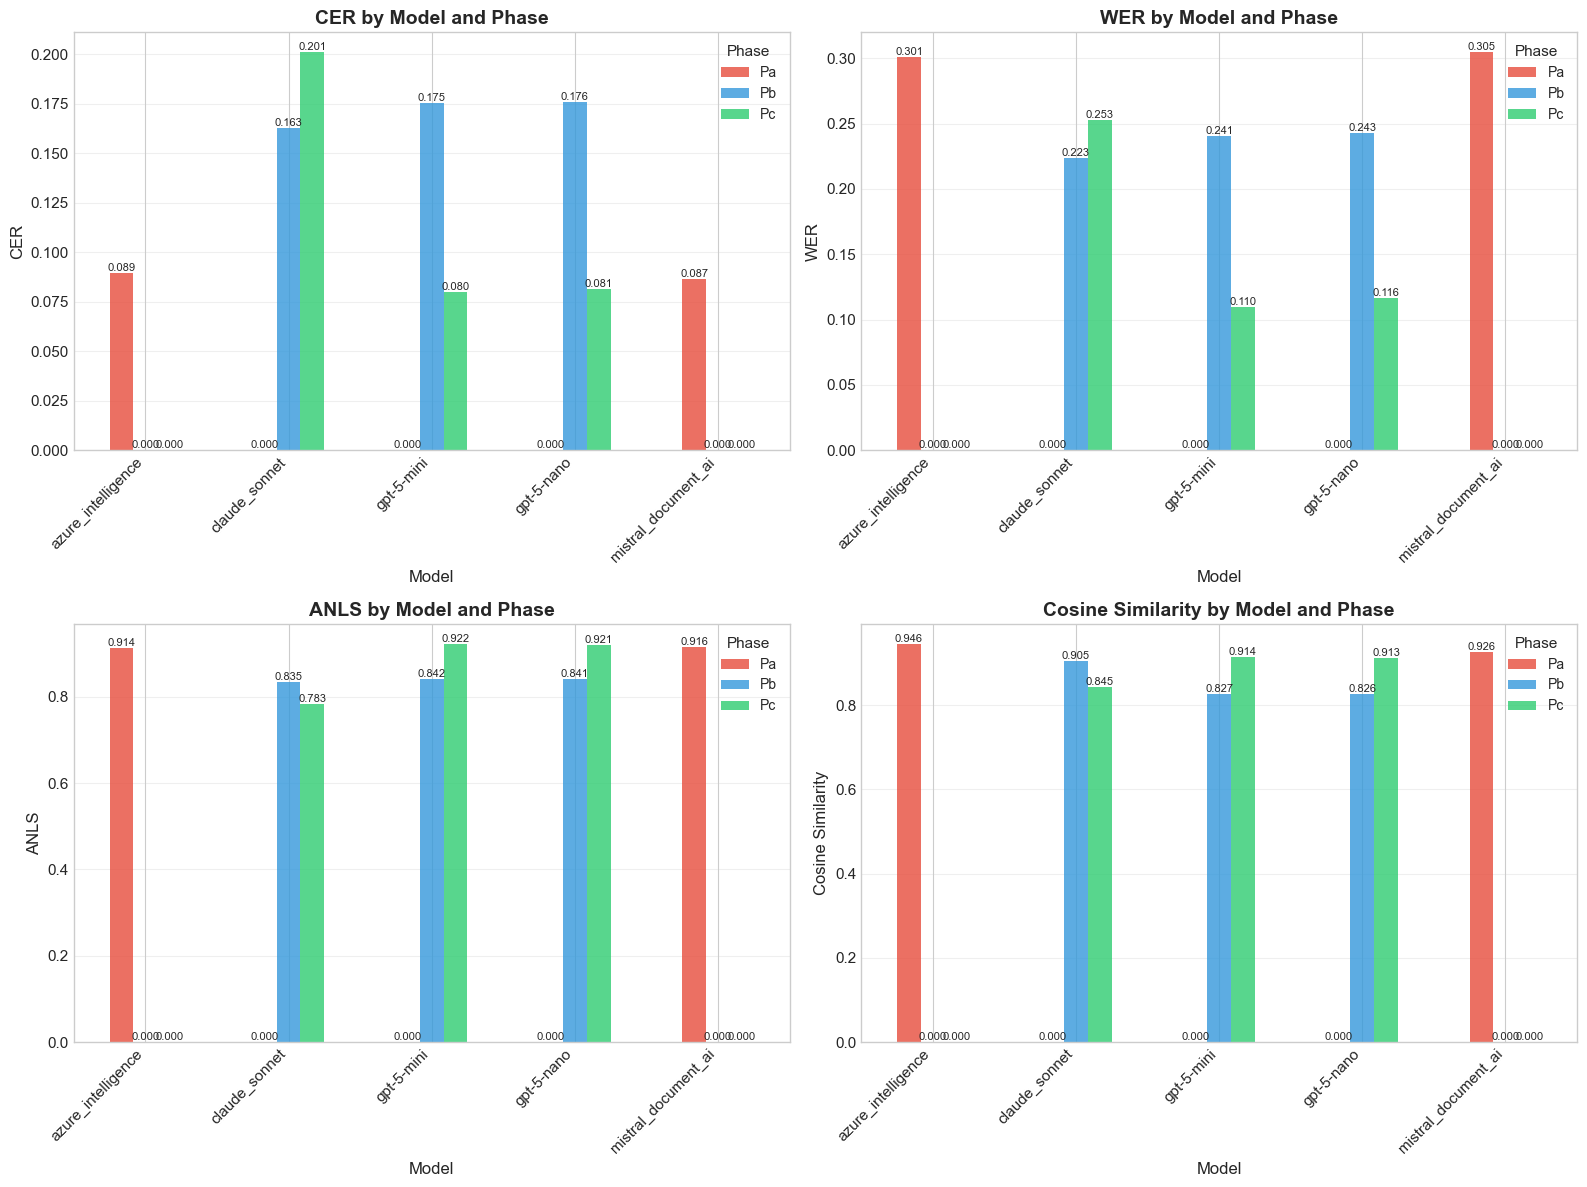

In [42]:
# Bar charts for each metric
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

metrics_to_plot = ['CER', 'WER', 'ANLS', 'Cosine Similarity']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    
    # Pivot data for grouped bar chart
    pivot_data = summary_df.pivot(index='Model', columns='Phase', values=metric)
    
    pivot_data.plot(kind='bar', ax=ax, color=['#e74c3c', '#3498db', '#2ecc71'], alpha=0.8)
    
    ax.set_title(f'{metric} by Model and Phase', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.legend(title='Phase', title_fontsize=11, fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    
    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=8)

plt.tight_layout()
plt.show()


### Box Plot Distribution Analysis

Identical embeddings for sample iam_153_c03-003d, model claude_sonnet
Identical embeddings for sample iam_207_d06-037, model claude_sonnet
Identical embeddings for sample iam_484_l04-071, model claude_sonnet
Identical embeddings for sample iam_052_a03-043, model gpt-5-mini
Identical embeddings for sample iam_094_b01-127, model gpt-5-mini
Identical embeddings for sample iam_152_c03-096c, model gpt-5-mini
Identical embeddings for sample iam_153_c03-096d, model gpt-5-mini
Identical embeddings for sample iam_181_d01-118, model gpt-5-mini
Identical embeddings for sample iam_340_g06-045i, model gpt-5-mini
Identical embeddings for sample iam_384_h06-079, model gpt-5-mini
Identical embeddings for sample iam_469_l01-143, model gpt-5-mini
Identical embeddings for sample iam_541_m03-095, model gpt-5-mini
Identical embeddings for sample iam_052_a03-043, model gpt-5-nano
Identical embeddings for sample iam_094_b01-127, model gpt-5-nano
Identical embeddings for sample iam_152_c03-096c, model gpt-5-n

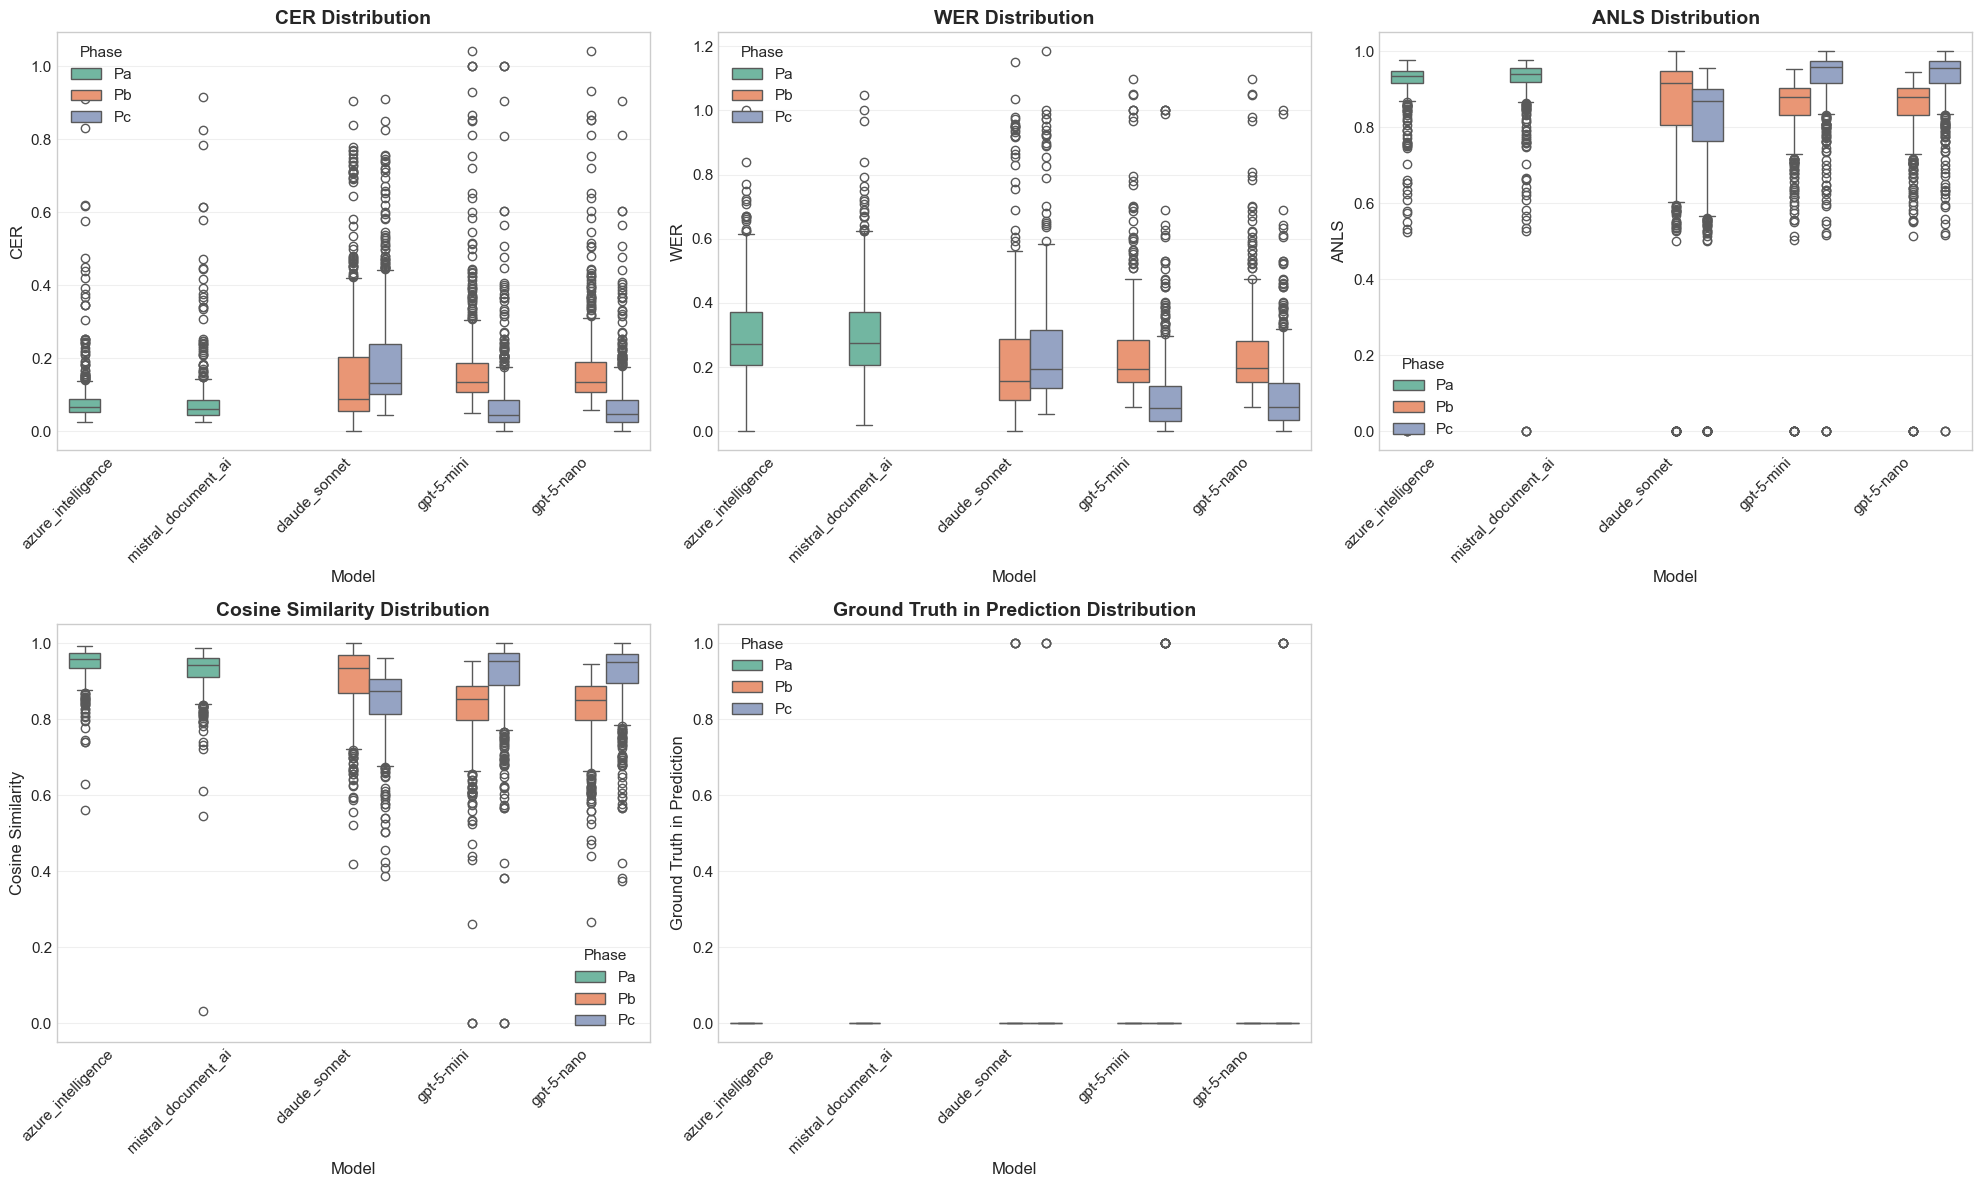

In [43]:
# Calculate per-sample metrics for box plots
sample_metrics_data = []

for phase, df in phase_dfs.items():
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        
        for _, row in df.iterrows():
            metrics = calculate_sample_metrics(row['ground_truth'], row[pred_col], phase, row['sample_id'], model, embedding_manager)
            
            sample_metrics_data.append({
                'Phase': phase,
                'Model': model,
                'CER': metrics['cer'],
                'WER': metrics['wer'],
                'ANLS': metrics['anls'],
                'Cosine Similarity': metrics['cosine_similarity'],
                'Ground Truth in Prediction': metrics['ground_truth_in_prediction']
            })

sample_metrics_df = pd.DataFrame(sample_metrics_data)

# Create box plots
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, metric in enumerate(['CER', 'WER', 'ANLS', 'Cosine Similarity', 'Ground Truth in Prediction']):
    ax = axes[idx]
    
    # Create box plot
    sns.boxplot(data=sample_metrics_df, x='Model', y=metric, hue='Phase', ax=ax, palette='Set2')
    
    ax.set_title(f'{metric} Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

# Hide the extra subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

### Heatmap: Model vs Metric Performance

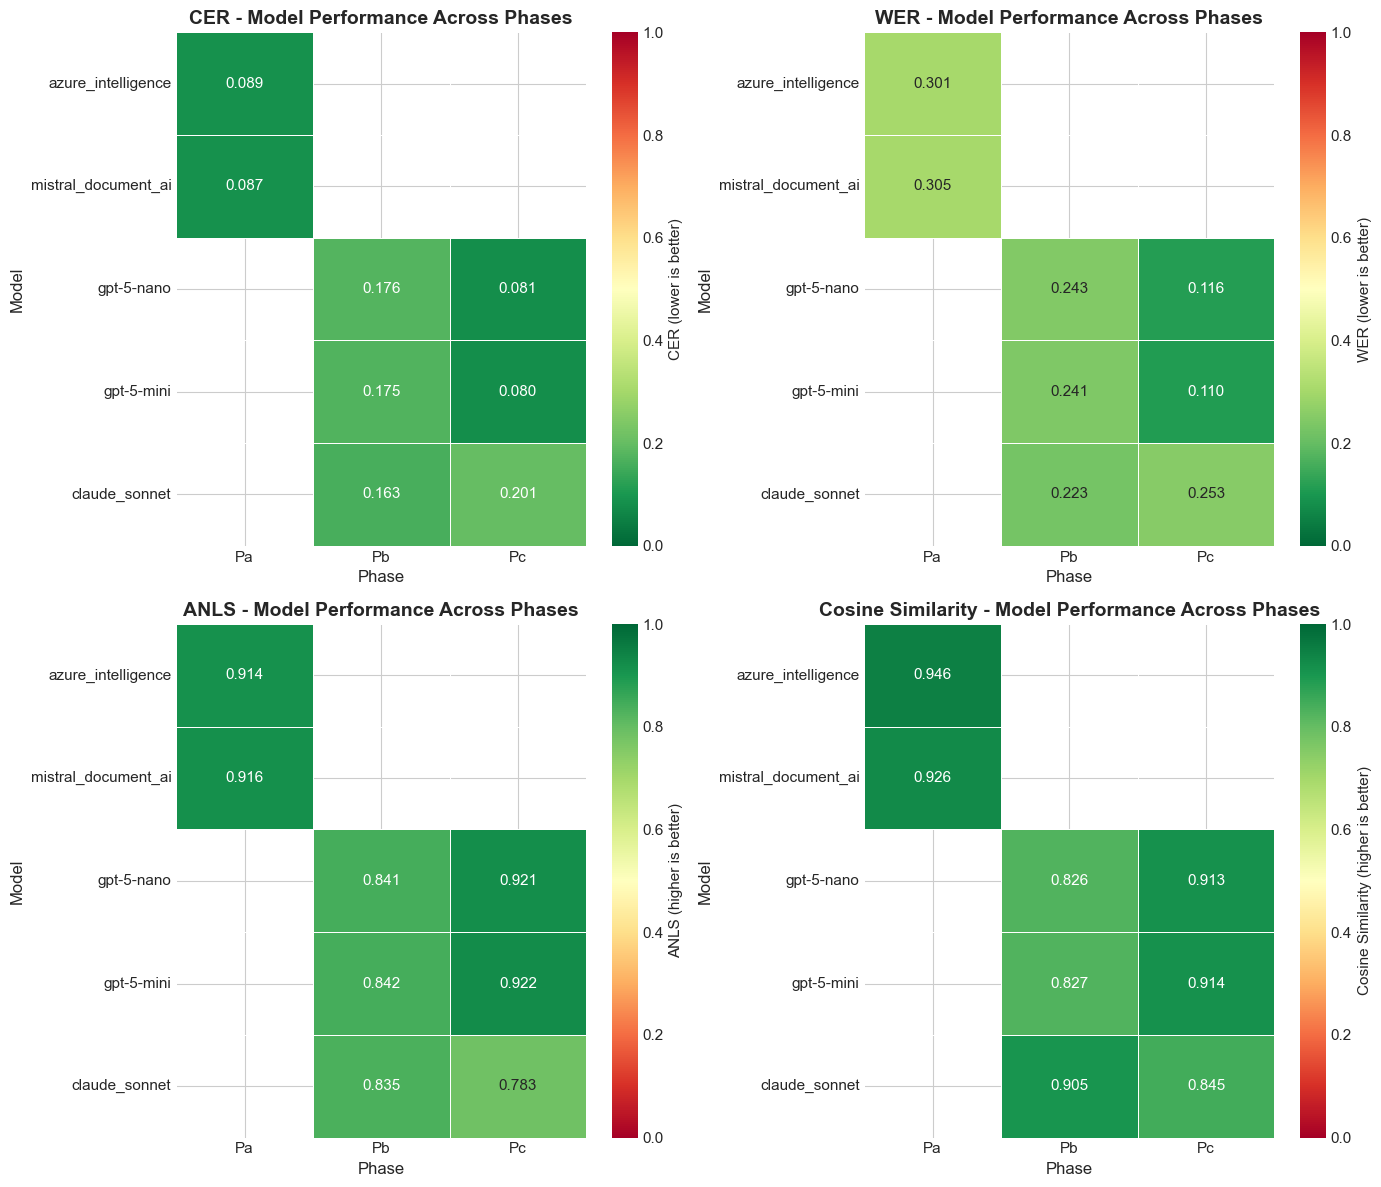

In [44]:
# Create heatmaps for each metric
metrics_to_show = ['CER', 'WER', 'ANLS', 'Cosine Similarity']
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, metric_name in enumerate(metrics_to_show):
    ax = axes[idx]
    
    # Create heatmap data: rows = models, columns = phases
    heatmap_data = []
    model_names = []
    phase_names = list(metrics_results.keys())
    
    # Get all unique models across all phases and sort them according to MODEL_ORDER
    all_models = set()
    for phase_models in metrics_results.values():
        all_models.update(phase_models.keys())
    all_models = sort_models(list(all_models))
    
    # Build heatmap data
    for model in all_models:
        row_data = []
        for phase in phase_names:
            if model in metrics_results[phase]:
                # Get the metric value based on metric_name
                if metric_name == 'CER':
                    value = metrics_results[phase][model]['cer']
                elif metric_name == 'WER':
                    value = metrics_results[phase][model]['wer']
                elif metric_name == 'ANLS':
                    value = metrics_results[phase][model]['anls']
                elif metric_name == 'Cosine Similarity':
                    value = metrics_results[phase][model]['cosine_similarity']
                else:
                    value = np.nan
                row_data.append(value)
            else:
                row_data.append(np.nan)
        
        heatmap_data.append(row_data)
        model_names.append(model)
    
    heatmap_df = pd.DataFrame(
        heatmap_data,
        index=model_names,
        columns=phase_names
    )
    
    # Set colormap and label based on metric type
    if metric_name in ['CER', 'WER']:
        # Lower is better for error rates - use reversed colormap (green for low, red for high)
        cmap = 'RdYlGn_r'
        cbar_label = f'{metric_name} (lower is better)'
    else:
        # Higher is better for ANLS and Cosine Similarity - use normal colormap (green for high, red for low)
        cmap = 'RdYlGn'
        cbar_label = f'{metric_name} (higher is better)'
    
    sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap=cmap, 
                ax=ax, cbar_kws={'label': cbar_label}, 
                vmin=0, vmax=1, linewidths=0.5)
    
    ax.set_title(f'{metric_name} - Model Performance Across Phases', fontsize=14, fontweight='bold')
    ax.set_xlabel('Phase', fontsize=12)
    ax.set_ylabel('Model', fontsize=12)

plt.tight_layout()
plt.show()

### Scatter Plot: CER vs WER Correlation

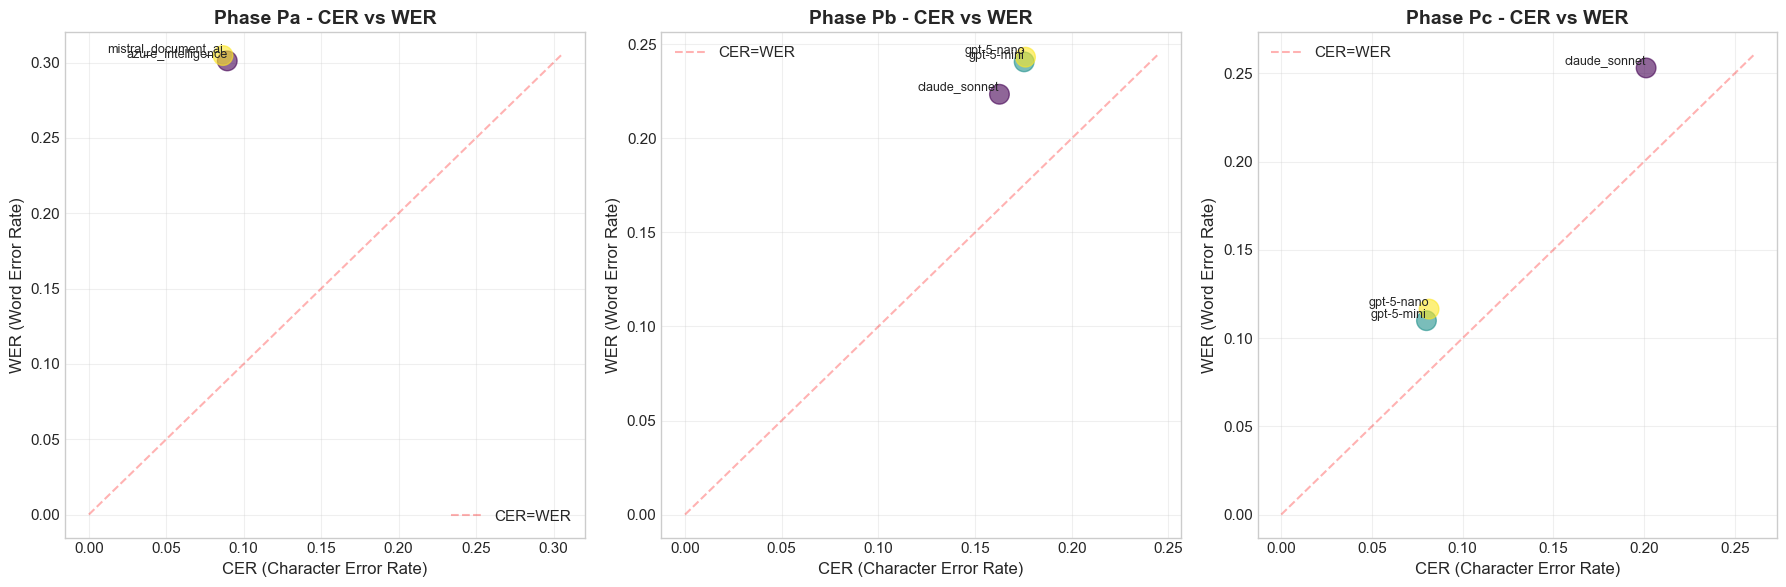

In [ ]:
# Scatter plot of CER vs WER for each phase
fig, axes = plt.subplots(1, len(metrics_results), figsize=(6 * len(metrics_results), 6))

if len(metrics_results) == 1:
    axes = [axes]

for idx, phase in enumerate(metrics_results.keys()):
    ax = axes[idx]
    
    phase_data = summary_df[summary_df['Phase'] == phase]
    
    scatter = ax.scatter(phase_data['CER'], phase_data['WER'], 
                        s=200, alpha=0.6, c=range(len(phase_data)), cmap='viridis')
    
    # Add model labels
    for _, row in phase_data.iterrows():
        ax.annotate(row['Model'], (row['CER'], row['WER']), 
                   fontsize=9, ha='right', va='bottom')
    
    ax.set_title(f'Phase {phase} - CER vs WER', fontsize=14, fontweight='bold')
    ax.set_xlabel('CER (Character Error Rate)', fontsize=12)
    ax.set_ylabel('WER (Word Error Rate)', fontsize=12)
    ax.grid(alpha=0.3)
    
    # Add diagonal reference line
    lims = [0, max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'r--', alpha=0.3, label='CER=WER')
    ax.legend()

plt.tight_layout()
plt.show()

### Error Analysis: Best and Worst Samples

In [46]:
# Analyze best and worst performing samples for Pa phase
if 'Pa' in phase_dfs:
    df_analysis = phase_dfs['Pa'].copy()
    
    # Get first model for analysis
    pred_cols = [col for col in df_analysis.columns if col.startswith('prediction_')]
    first_model = pred_cols[0].replace('prediction_', '')
    
    # Calculate CER for each sample
    df_analysis['cer'] = df_analysis.apply(
        lambda row: calculate_cer(row['ground_truth'], row[f'prediction_{first_model}']),
        axis=1
    )
    
    # Get best and worst samples
    best_samples = df_analysis.nsmallest(5, 'cer')
    worst_samples = df_analysis.nlargest(5, 'cer')
    
    print("\n" + "="*120)
    print(f"BEST PERFORMING SAMPLES (Lowest CER) - Model: {first_model}")
    print("="*120)
    
    for _, row in best_samples.iterrows():
        print(f"\nSample: {row['sample_id']} | CER: {row['cer']:.4f}")
        print(f"Ground Truth: {row['ground_truth'][:100]}..." if len(str(row['ground_truth'])) > 100 else f"Ground Truth: {row['ground_truth']}")
        pred_text = str(row[f'prediction_{first_model}'])
        print(f"Prediction:   {pred_text[:100]}..." if len(pred_text) > 100 else f"Prediction:   {pred_text}")
    
    print("\n" + "="*120)
    print(f"WORST PERFORMING SAMPLES (Highest CER) - Model: {first_model}")
    print("="*120)
    
    for _, row in worst_samples.iterrows():
        print(f"\nSample: {row['sample_id']} | CER: {row['cer']:.4f}")
        print(f"Ground Truth: {row['ground_truth'][:100]}..." if len(str(row['ground_truth'])) > 100 else f"Ground Truth: {row['ground_truth']}")
        pred_text = str(row[f'prediction_{first_model}'])
        print(f"Prediction:   {pred_text[:100]}..." if len(pred_text) > 100 else f"Prediction:   {pred_text}")


BEST PERFORMING SAMPLES (Lowest CER) - Model: azure_intelligence

Sample: iam_401_j04-012 | CER: 0.0247
Ground Truth: knowing the time of separation and the
activity of the lead-210 solution , the ingrowth
of the bismu...
Prediction:   Knowing the time of separation and the activity of the lead-210 solution, the ingrowth
of the bismut...

Sample: iam_300_g01-070 | CER: 0.0296
Ground Truth: Again the resentment was widespread and
the results disappointing - a tax estimated
to yield 50,000 ...
Prediction:   Again the resentment was widespread and the results disappointing - a tax estimated
to yield 50,000 ...

Sample: iam_341_g06-042j | CER: 0.0296
Ground Truth: Nor is this to be wondered at for even today.
in the 1960s, no cure has been found for
the 6tic doul...
Prediction:   Nor is this to be wondered at, for even today, in the 1960s, no cure has been found for
the 6tic dou...

Sample: iam_247_e07-086 | CER: 0.0298
Ground Truth: It is not easy to make an economic
comparison between c

### Inference Time Analysis


Inference Time Summary:


,Phase,Model,Mean Time (ms),Median Time (ms)
1,Pa,mistral_document_ai,1892.526810,1755.724549
0,Pa,azure_intelligence,3105.829107,2527.125478
2,Pb,claude_sonnet,5363.110452,5236.725569
3,Pb,gpt-5-mini,6785.945541,6266.958833
4,Pb,gpt-5-nano,8837.456888,8006.462097
5,Pc,claude_sonnet,5512.415502,5326.512814
6,Pc,gpt-5-mini,7367.602905,6675.794959
7,Pc,gpt-5-nano,9313.570643,8692.848086


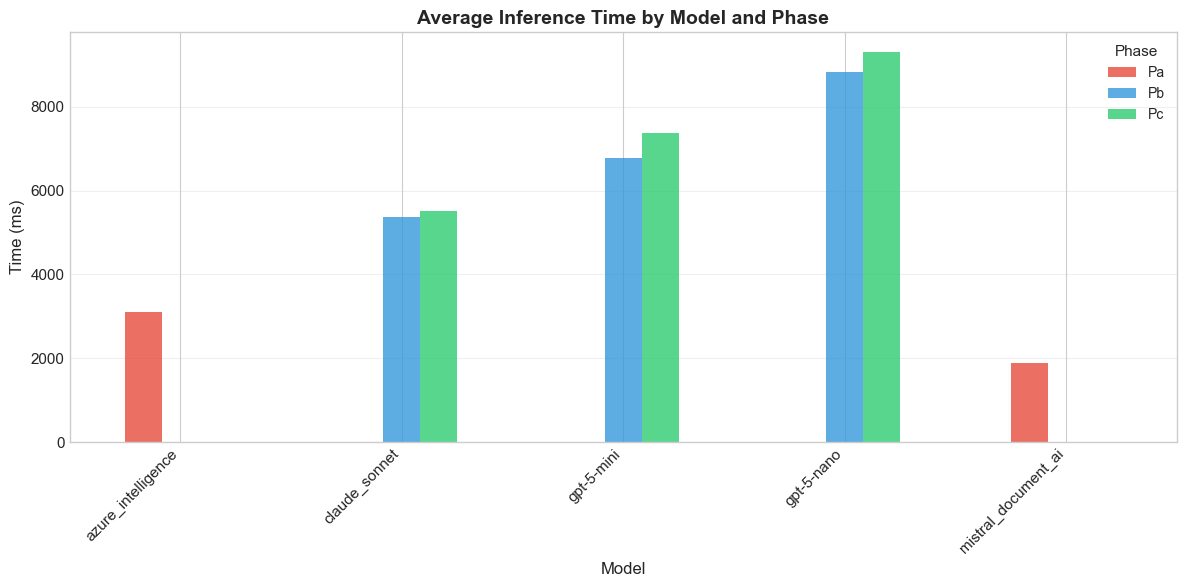

In [47]:
# Analyze inference times across models and phases
inference_data = []

for phase, df in phase_dfs.items():
    time_cols = [col for col in df.columns if col.startswith('inference_time_ms_')]
    
    for time_col in time_cols:
        model = time_col.replace('inference_time_ms_', '')
        
        mean_time = df[time_col].mean()
        median_time = df[time_col].median()
        
        inference_data.append({
            'Phase': phase,
            'Model': model,
            'Mean Time (ms)': mean_time,
            'Median Time (ms)': median_time
        })

if inference_data:
    inference_df = pd.DataFrame(inference_data)
    
    print("\nInference Time Summary:")
    print("="*100)
    display(inference_df.sort_values(['Phase', 'Mean Time (ms)']))
    
    # Visualization
    fig, ax = plt.subplots(figsize=(12, 6))
    
    pivot_time = inference_df.pivot(index='Model', columns='Phase', values='Mean Time (ms)')
    pivot_time.plot(kind='bar', ax=ax, color=['#e74c3c', '#3498db', '#2ecc71'], alpha=0.8)
    
    ax.set_title('Average Inference Time by Model and Phase', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('Time (ms)', fontsize=12)
    ax.legend(title='Phase', title_fontsize=11, fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
else:
    print("No inference time data available")

## 6. Save Embeddings Cache

Save any newly computed embeddings to disk for faster future runs.

In [48]:
# Save any newly computed embeddings to disk for future use
if embedding_manager.modified_phases:
    print("💾 Saving newly computed embeddings...")
    saved_files = embedding_manager.save_new_embeddings()
    for f in saved_files:
        print(f"   ✅ Saved: {f}")
    print(f"\n📁 Embeddings saved to {EMBEDDINGS_DIR.resolve()}")
    print("   Next run will load these embeddings from cache (much faster!)")
else:
    print("✨ All embeddings were loaded from cache - no new embeddings to save.")

✨ All embeddings were loaded from cache - no new embeddings to save.


## Conclusion

This notebook provides a comprehensive analysis of handwriting recognition performance across OCR and VLM models.

**Key Deliverables:**
- Quantitative metrics (CER, WER, ANLS, Cosine Similarity) for all models
- Visual comparisons across phases and models
- Error analysis identifying strengths and weaknesses
- Inference time benchmarks

**Next Steps:**
- Use LLM to generate natural language insights
- Identify specific handwriting styles that cause issues
- Recommend optimal model selection strategy